# Projeto: Bank Marketing (UCI Machine Learning Repository)

Estes dados estão relacionados a campanhas de marketing, baseadas em ligações telefônicas, de uma instituição bancária portuguesa.

As campanhas de marketing foram realizadas por meio de chamadas telefônicas. Frequentemente, foram necessários mais de um contato com o mesmo cliente para avaliar se o produto (depósito a prazo bancário) vai ser obtido ou não.

## 2. Importando as bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(pd.__version__)

3.0.4


### 2.1 Lendo os dados da campanha de marketing

In [4]:
df = pd.read_csv('../data/bank-full.csv', sep= ';', encoding='utf-8')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


## 3. Qual a distribuição da idade dos clientes no dataset?

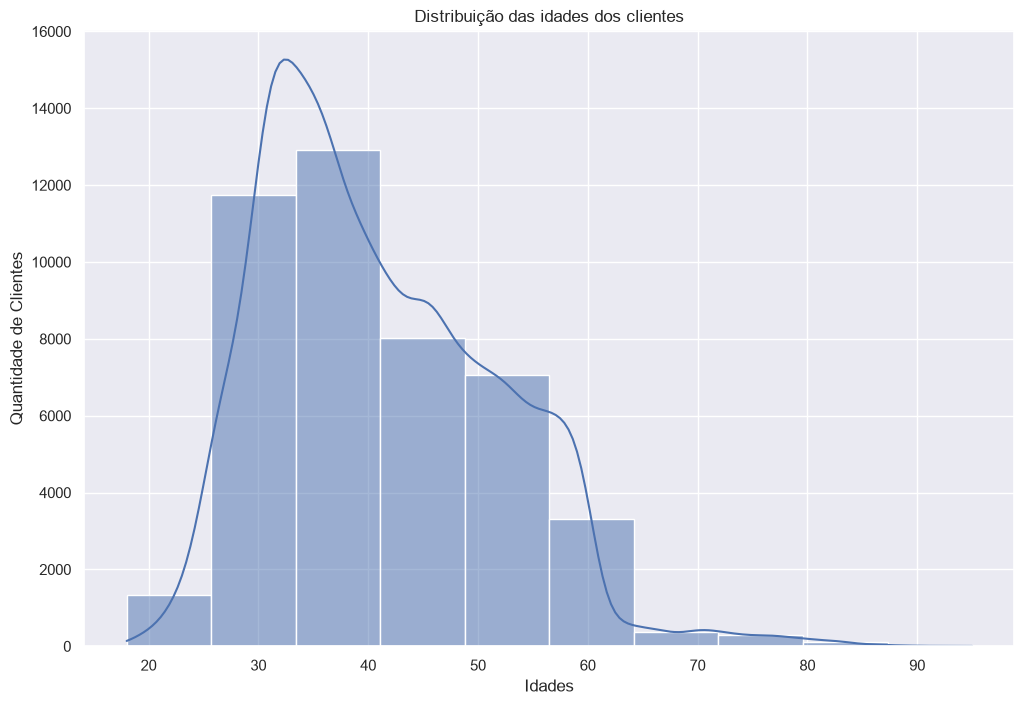

In [10]:
plt.figure(figsize=(12,8))

sns.set_theme(style='darkgrid')

sns.histplot(
    data=df,
    x='age',
    bins=10,
    kde=True
)

plt.title('Distribuição das idades dos clientes')
plt.xlabel('Idades')
plt.ylabel('Quantidade de Clientes')
plt.show()

A distribuição das idades não segue um padrão simétrico, apresentando assimetria à direita, com predominância de clientes entre 30 e 40 anos e redução gradual da frequência nas idades mais elevadas. A presença de uma cauda longa indica que existem poucos clientes idosos, enquanto a maior parte da população concentra-se em uma faixa etária entre 30 e 50 anos. Esse comportamento é típico de bases de clientes compostas predominantemente por adultos em idade economicamente ativa e deve ser considerado em análises estatísticas e na definição de estratégias de negócio.

## 4. Qual é a distribuição das profissões? E qual é a profissão mais comum entre os clientes?

In [14]:
# Contagem das profissões
contagem_job = df['job'].value_counts().reset_index()

# Renomear as colunas
contagem_job.columns = ['Profissão', 'Quantidade']

contagem_job

,Profissão,Quantidade
0,blue-collar,9732
1,management,9458
2,technician,7597
3,admin.,5171
4,services,4154
5,retired,2264
6,self-employed,1579
7,entrepreneur,1487
8,unemployed,1303
9,housemaid,1240


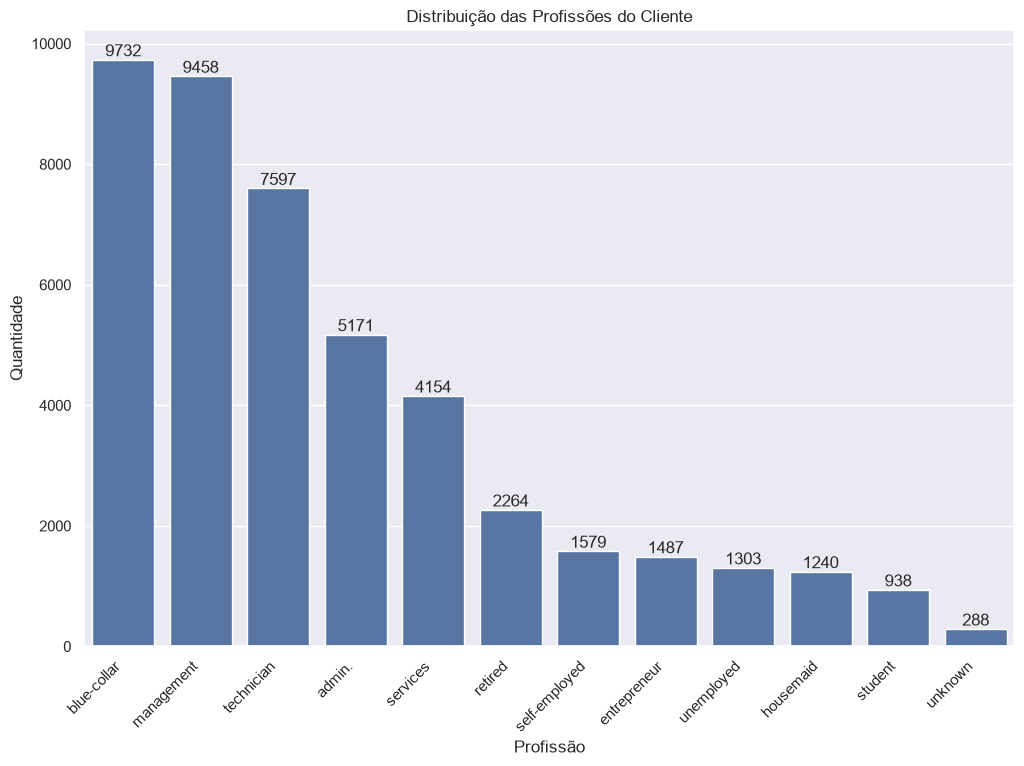

In [18]:
plt.figure(figsize=(12,8))

ax = sns.barplot(
    data=contagem_job,
    x='Profissão',
    y='Quantidade'
)

# Adicionar os rótulos
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribuição das Profissões do Cliente')
plt.xlabel('Profissão')
plt.ylabel('Quantidade')
plt.xticks(rotation=45, ha='right')
plt.show()

A análise da distribuição das profissões mostra que operários (blue-collar) representam o maior grupo de clientes da instituição financeira. No entanto, observa-se que a quantidade de clientes da categoria gerentes (management) é bastante próxima, indicando que ambos os segmentos possuem elevada representatividade na carteira.

Sob a perspectiva de negócio, esse resultado sugere que estratégias comerciais, campanhas de marketing e o desenvolvimento de produtos devem considerar esses dois perfis como públicos prioritários. Embora os operários constituam a maior parcela da base de clientes, a forte presença de gerentes indica uma oportunidade para a oferta de produtos e serviços diferenciados, alinhados às características e necessidades de cada segmento, contribuindo para aumentar a efetividade das ações comerciais e a rentabilidade da carteira.